In [33]:
#Importing required modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

## Exploring the data

In [34]:
data = yf.download('AAPL',start='2020-01-01', end='2024-12-31')
data.head()

C:\Users\rasul\AppData\Local\Temp\ipykernel_28080\844287536.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL',start='2020-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.538513,72.598892,71.292304,71.545890,135480400
2020-01-03,71.833275,72.594040,71.608669,71.765651,146322800
2020-01-06,72.405678,72.444321,70.703012,70.954188,118387200
2020-01-07,72.065155,72.671348,71.845377,72.415345,108872000
2020-01-08,73.224419,73.526310,71.768094,71.768094,132079200


In [35]:
# Gives summary statistics for all numeric columns in the database
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03
mean,151.728301,153.253333,150.026016,151.571824,9.061168e+07
std,41.896383,42.035036,41.671141,41.835807,5.324605e+07
min,54.316936,55.316755,51.470001,55.215079,2.323470e+07
25%,126.607071,127.694603,124.586290,126.080072,5.546960e+07
50%,150.366409,152.119782,148.366937,150.191808,7.629970e+07
75%,176.243683,177.947034,174.809393,176.090157,1.077601e+08
max,258.103729,259.179926,256.718662,257.276679,4.265100e+08


In [36]:
# Gives metadata about the DataFrame
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2020-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1257 non-null   float64
 1   (High, AAPL)    1257 non-null   float64
 2   (Low, AAPL)     1257 non-null   float64
 3   (Open, AAPL)    1257 non-null   float64
 4   (Volume, AAPL)  1257 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


In [37]:
# Checks for missing values (NaN) in DataFrame
data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

## Plotting the closing price

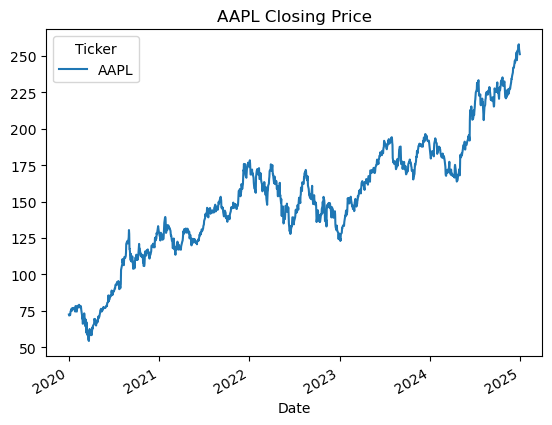

In [38]:
data['Close'].plot(title='AAPL Closing Price')
plt.show()

## Computing Returns

Daily Return → how much the price changed from one day to the next

Cumulative Return → how much your total investment has grown over time

In [39]:
# Daily Returns
# .pct_change is a Pandas function that computes the percentage change between the current value and the previous value.

data['Daily Return'] = data['Close'].pct_change()


In [40]:
# Cumulative Returns
# .cumprod() : cumulative product — it multiplies each day’s growth factor by all previous ones.

data['Cumulative Return'] = (1 + data['Daily Return']).cumprod()

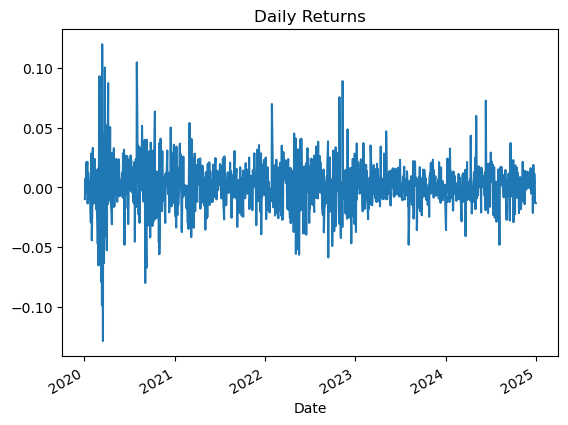

In [41]:
data['Daily Return'].plot(title="Daily Returns")
plt.show()

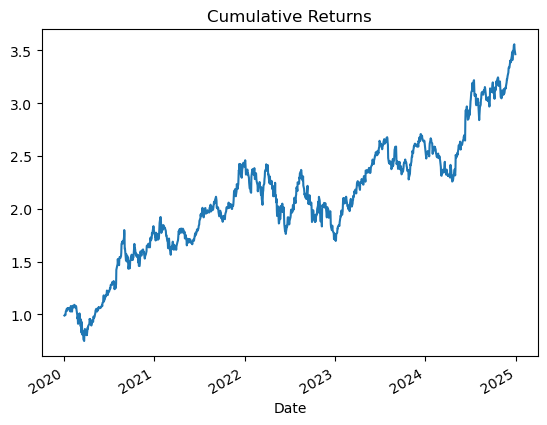

In [42]:
data["Cumulative Return"].plot(title="Cumulative Returns")
plt.show()

## Comparing 2 Stocks

In [78]:
dataComp = yf.download(['AAPL', 'MSFT'], start='2020-01-01', end='2023-12-31')
dataComp.head()

C:\Users\rasul\AppData\Local\Temp\ipykernel_28080\2625632662.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dataComp = yf.download(['AAPL', 'MSFT'], start='2020-01-01', end='2023-12-31')
[*********************100%***********************]  2 of 2 completed


Price           Close                   High                    Low  \
Ticker           AAPL        MSFT       AAPL        MSFT       AAPL   
Date                                                                  
2020-01-02  72.538513  152.791077  72.598892  152.895716  71.292304   
2020-01-03  71.833275  150.888626  72.594040  152.153802  71.608669   
2020-01-06  72.405685  151.278625  72.444328  151.345221  70.703020   
2020-01-07  72.065155  149.899323  72.671348  151.887449  71.845377   
2020-01-08  73.224419  152.286972  73.526310  152.962372  71.768094   

Price                        Open                 Volume            
Ticker            MSFT       AAPL        MSFT       AAPL      MSFT  
Date                                                                
2020-01-02  150.612702  71.545890  151.040765  135480400  22622100  
2020-01-03  150.355924  71.765651  150.603260  146322800  21116200  
2020-01-06  148.881450  70.954195  149.423674  118387200  20813700  
2020-01-07  149.652001  72.415345  151.554518  108872000  21634100  
2020-01-08  150.251279  71.768094  151.183509  132079200  27746500

In [79]:
# Extracting only the closing prices

close_data = dataComp['Close']

In [80]:
#Computing Daily Returns

daily_returns = close_data.pct_change()

#Computing Cumulative Returns

cumulative_returns = (1+daily_returns).cumprod()
print(cumulative_returns.columns)


Index(['AAPL', 'MSFT'], dtype='object', name='Ticker')


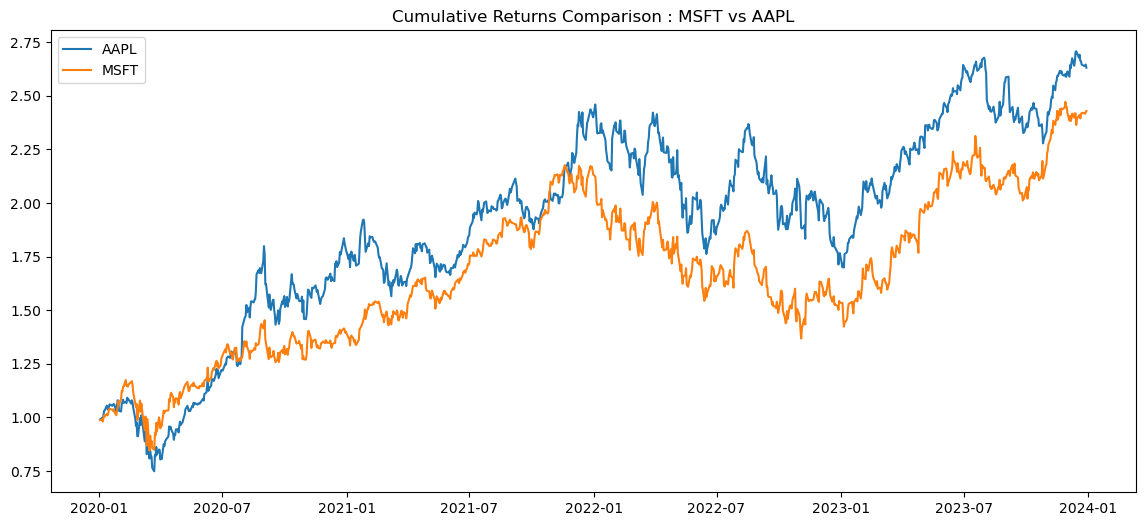

In [81]:
plt.figure(figsize=(14,6))
plt.plot(cumulative_returns.index, cumulative_returns['AAPL'], label='AAPL')
plt.plot(cumulative_returns.index, cumulative_returns['MSFT'], label='MSFT')
plt.title("Cumulative Returns Comparison : MSFT vs AAPL")
plt.legend()
plt.show()

## Basic Statistics

In [82]:
# The mean daily return shows the average percentage change per day

mean_daily_returns = daily_returns.mean()
print("Mean Daily Returns:")
print(mean_daily_returns)


Mean Daily Returns:
Ticker
AAPL    0.001187
MSFT    0.001095
dtype: float64


In [83]:
# Volatility (Standard Deviation)
# The standard deviation of daily returns measures how much returns fluctuate (risk)

volatility = daily_returns.std()
print("Volatility (Standard Deviation):")
print(volatility)


Volatility (Standard Deviation):
Ticker
AAPL    0.021146
MSFT    0.020546
dtype: float64


In [84]:
# The Sharpe Ratio measures risk-adjusted performance — i.e., how much return you’re getting per unit of risk.
# 252 is number of trading days in a year

sharpe_ratio = (mean_daily_returns / volatility) * np.sqrt(252)
print("Sharpe Ratio (Annualized):")
print(sharpe_ratio)


Sharpe Ratio (Annualized):
Ticker
AAPL    0.890771
MSFT    0.845753
dtype: float64


## Visualisation